In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Create folders if they don't exist
os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [8]:
sectors = {
    "Banking": [
        "HDFCBANK.NS",
        "ICICIBANK.NS",
        "SBIN.NS",
        "AXISBANK.NS",
        "KOTAKBANK.NS",
        "INDUSINDBK.NS",
        "BANKBARODA.NS",
    ],
    "IT": [
        "TCS.NS",
        "INFY.NS",
        "WIPRO.NS",
        "HCLTECH.NS",
        "TECHM.NS",
        "MPHASIS.NS",
    ],
    "Auto": [
        "MARUTI.NS",
        "HEROMOTOCO.NS",
        "EICHERMOT.NS",
        "BAJAJ-AUTO.NS",
    ],
    "Energy": [
        "RELIANCE.NS",
        "ONGC.NS",
        "NTPC.NS",
        "POWERGRID.NS",
        "COALINDIA.NS",
    ],
}

# Flatten into one list for bulk download
all_tickers = [t for s in sectors.values() for t in s]

print(f"Total tickers : {len(all_tickers)}")
for name, tickers in sectors.items():
    print(f"  {name:10s} : {len(tickers)} stocks → {tickers}")

Total tickers : 22
  Banking    : 7 stocks → ['HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS', 'AXISBANK.NS', 'KOTAKBANK.NS', 'INDUSINDBK.NS', 'BANKBARODA.NS']
  IT         : 6 stocks → ['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS', 'TECHM.NS', 'MPHASIS.NS']
  Auto       : 4 stocks → ['MARUTI.NS', 'HEROMOTOCO.NS', 'EICHERMOT.NS', 'BAJAJ-AUTO.NS']
  Energy     : 5 stocks → ['RELIANCE.NS', 'ONGC.NS', 'NTPC.NS', 'POWERGRID.NS', 'COALINDIA.NS']


In [9]:
print("This takes about 30–60 seconds. Do not interrupt.\n")

raw = yf.download(
    tickers     = all_tickers,
    start       = "2015-01-01",
    end         = "2025-01-01",
    auto_adjust = True,
    progress    = True,
    group_by    = "column",
)

print(f"\nDownload complete!")
print(f"Raw data shape : {raw.shape}")

This takes about 30–60 seconds. Do not interrupt.



[*********************100%***********************]  22 of 22 completed


Download complete!
Raw data shape : (2467, 110)


In [10]:
# Pull only the Close column
prices = raw["Close"].copy()

# Newer yfinance returns MultiIndex columns like (HDFCBANK.NS, Close)
# This flattens it to just HDFCBANK.NS
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(0)

# Ensure index is proper datetime
prices.index = pd.to_datetime(prices.index)

print(f"Shape  : {prices.shape}  (rows = trading days, cols = stocks)")
print(f"Start  : {prices.index[0].date()}")
print(f"End    : {prices.index[-1].date()}")
print(f"\nSample (first 3 rows):")
print(prices.head(3).round(2))

Shape  : (2467, 22)  (rows = trading days, cols = stocks)
Start  : 2015-01-01
End    : 2024-12-31

Sample (first 3 rows):
Ticker      AXISBANK.NS  BAJAJ-AUTO.NS  BANKBARODA.NS  COALINDIA.NS  \
Date                                                                  
2015-01-01       486.96        1845.36         186.38        152.54   
2015-01-02       497.85        1845.06         188.65        153.22   
2015-01-05       501.00        1851.79         188.60        152.62   

Ticker      EICHERMOT.NS  HCLTECH.NS  HDFCBANK.NS  HEROMOTOCO.NS  \
Date                                                               
2015-01-01       1410.34      296.37       217.24        2197.23   
2015-01-02       1393.67      296.09       220.26        2192.06   
2015-01-05       1400.01      291.11       218.40        2207.13   

Ticker      ICICIBANK.NS  INDUSINDBK.NS  ...  MARUTI.NS  MPHASIS.NS  NTPC.NS  \
Date                                     ...                                   
2015-01-01        294

In [11]:
total_rows  = len(prices)
missing     = prices.isnull().sum()
missing_pct = (missing / total_rows * 100).round(2)

report = pd.DataFrame({
    "Missing Days"  : missing,
    "Missing %"     : missing_pct,
    "Available Days": total_rows - missing
}).sort_values("Missing %", ascending=False)

print("=== MISSING VALUE REPORT ===\n")
print(report.to_string())
print(f"\nTotal trading days   : {total_rows}")
print(f"Stocks with 0 missing: {(missing == 0).sum()}")
print(f"Stocks with any miss : {(missing  > 0).sum()}")

=== MISSING VALUE REPORT ===

               Missing Days  Missing %  Available Days
Ticker                                                
AXISBANK.NS               0        0.0            2467
BAJAJ-AUTO.NS             0        0.0            2467
BANKBARODA.NS             0        0.0            2467
COALINDIA.NS              0        0.0            2467
EICHERMOT.NS              0        0.0            2467
HCLTECH.NS                0        0.0            2467
HDFCBANK.NS               0        0.0            2467
HEROMOTOCO.NS             0        0.0            2467
ICICIBANK.NS              0        0.0            2467
INDUSINDBK.NS             0        0.0            2467
INFY.NS                   0        0.0            2467
KOTAKBANK.NS              0        0.0            2467
MARUTI.NS                 0        0.0            2467
MPHASIS.NS                0        0.0            2467
NTPC.NS                   0        0.0            2467
ONGC.NS                   0        

In [13]:
print(f"Before cleaning:")
print(f"  Shape         : {prices.shape}")
print(f"  Total missing : {prices.isnull().sum().sum()}")

# Step 1: forward-fill — carry last valid price forward into holiday gaps
prices_clean = prices.ffill()

# Step 2: drop rows still NaN at the very start (before a stock was listed)
prices_clean = prices_clean.dropna()

# Step 3: drop any stock with more than 10% missing before cleaning
bad_stocks = missing_pct[missing_pct > 10.0].index.tolist()
if bad_stocks:
    print(f"\n  Dropping (>10% missing): {bad_stocks}")
    prices_clean = prices_clean.drop(columns=bad_stocks)
else:
    print(f"\n  No stocks dropped — all passed 10% threshold")

print(f"\nAfter cleaning:")
print(f"  Shape         : {prices_clean.shape}")
print(f"  Total missing : {prices_clean.isnull().sum().sum()}")
print("\nCleaning done!")


Before cleaning:
  Shape         : (2467, 22)
  Total missing : 0

  No stocks dropped — all passed 10% threshold

After cleaning:
  Shape         : (2467, 22)
  Total missing : 0

Cleaning done!


In [14]:
print("=== LATEST PRICES (most recent trading day) ===")
print(f"As of : {prices_clean.index[-1].date()}\n")

latest = prices_clean.iloc[-1].sort_values(ascending=False)
for ticker, price in latest.items():
    print(f"  {ticker:22s}  Rs.{price:,.2f}")

print("\n=== PRICE STATISTICS ===")
print(prices_clean.describe().round(2))

=== LATEST PRICES (most recent trading day) ===
As of : 2024-12-31

  MARUTI.NS               Rs.10,742.13
  BAJAJ-AUTO.NS           Rs.8,581.12
  EICHERMOT.NS            Rs.4,760.18
  HEROMOTOCO.NS           Rs.3,921.86
  TCS.NS                  Rs.3,886.50
  MPHASIS.NS              Rs.2,791.42
  HCLTECH.NS              Rs.1,833.88
  INFY.NS                 Rs.1,825.96
  TECHM.NS                Rs.1,658.22
  ICICIBANK.NS            Rs.1,271.84
  RELIANCE.NS             Rs.1,210.61
  AXISBANK.NS             Rs.1,063.79
  INDUSINDBK.NS           Rs.960.15
  HDFCBANK.NS             Rs.874.60
  SBIN.NS                 Rs.779.30
  KOTAKBANK.NS            Rs.356.80
  COALINDIA.NS            Rs.353.70
  NTPC.NS                 Rs.322.26
  POWERGRID.NS            Rs.295.47
  WIPRO.NS                Rs.282.95
  BANKBARODA.NS           Rs.232.54
  ONGC.NS                 Rs.222.54

=== PRICE STATISTICS ===
Ticker  AXISBANK.NS  BAJAJ-AUTO.NS  BANKBARODA.NS  COALINDIA.NS  EICHERMOT.NS  \
count   

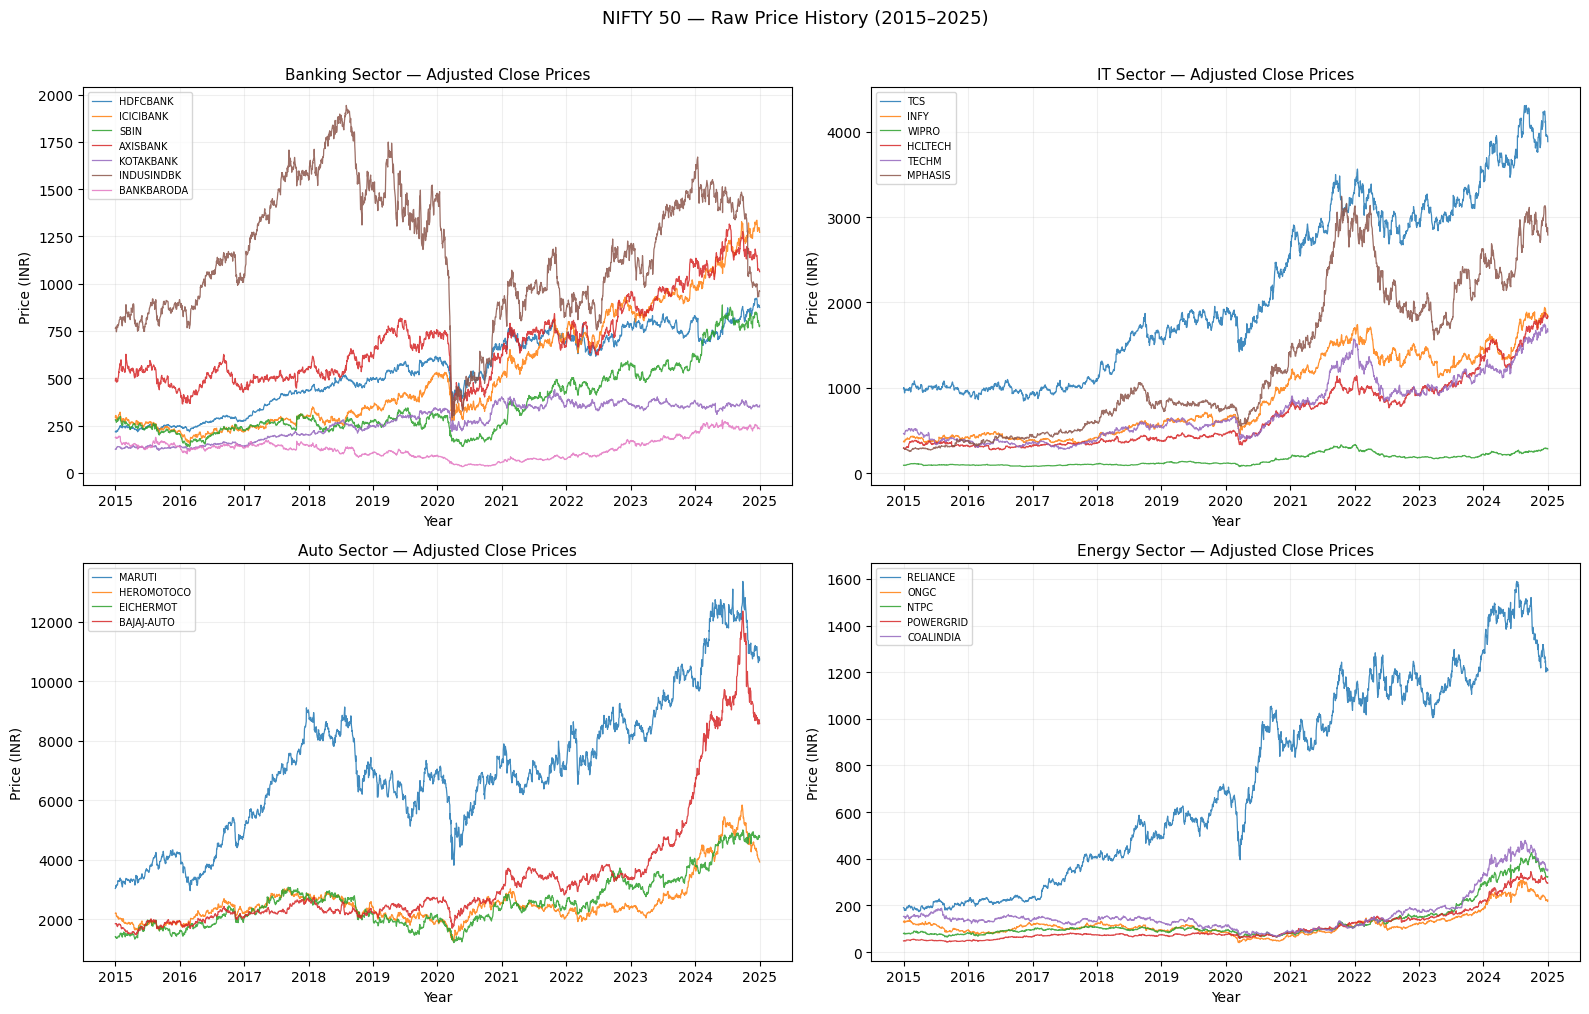

Saved: outputs/01_raw_prices.png


In [15]:
import matplotlib.dates as mdates

colors = plt.cm.tab10.colors
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (sector_name, tickers) in enumerate(sectors.items()):
    ax    = axes[idx]
    valid = [t for t in tickers if t in prices_clean.columns]

    for i, ticker in enumerate(valid):
        ax.plot(
            prices_clean.index,
            prices_clean[ticker],
            label     = ticker.replace(".NS", ""),
            color     = colors[i],
            linewidth = 0.9,
            alpha     = 0.85,
        )

    ax.set_title(f"{sector_name} Sector — Adjusted Close Prices", fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Price (INR)")
    ax.legend(fontsize=7, loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.2)

plt.suptitle("NIFTY 50 — Raw Price History (2015–2025)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/01_raw_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/01_raw_prices.png")

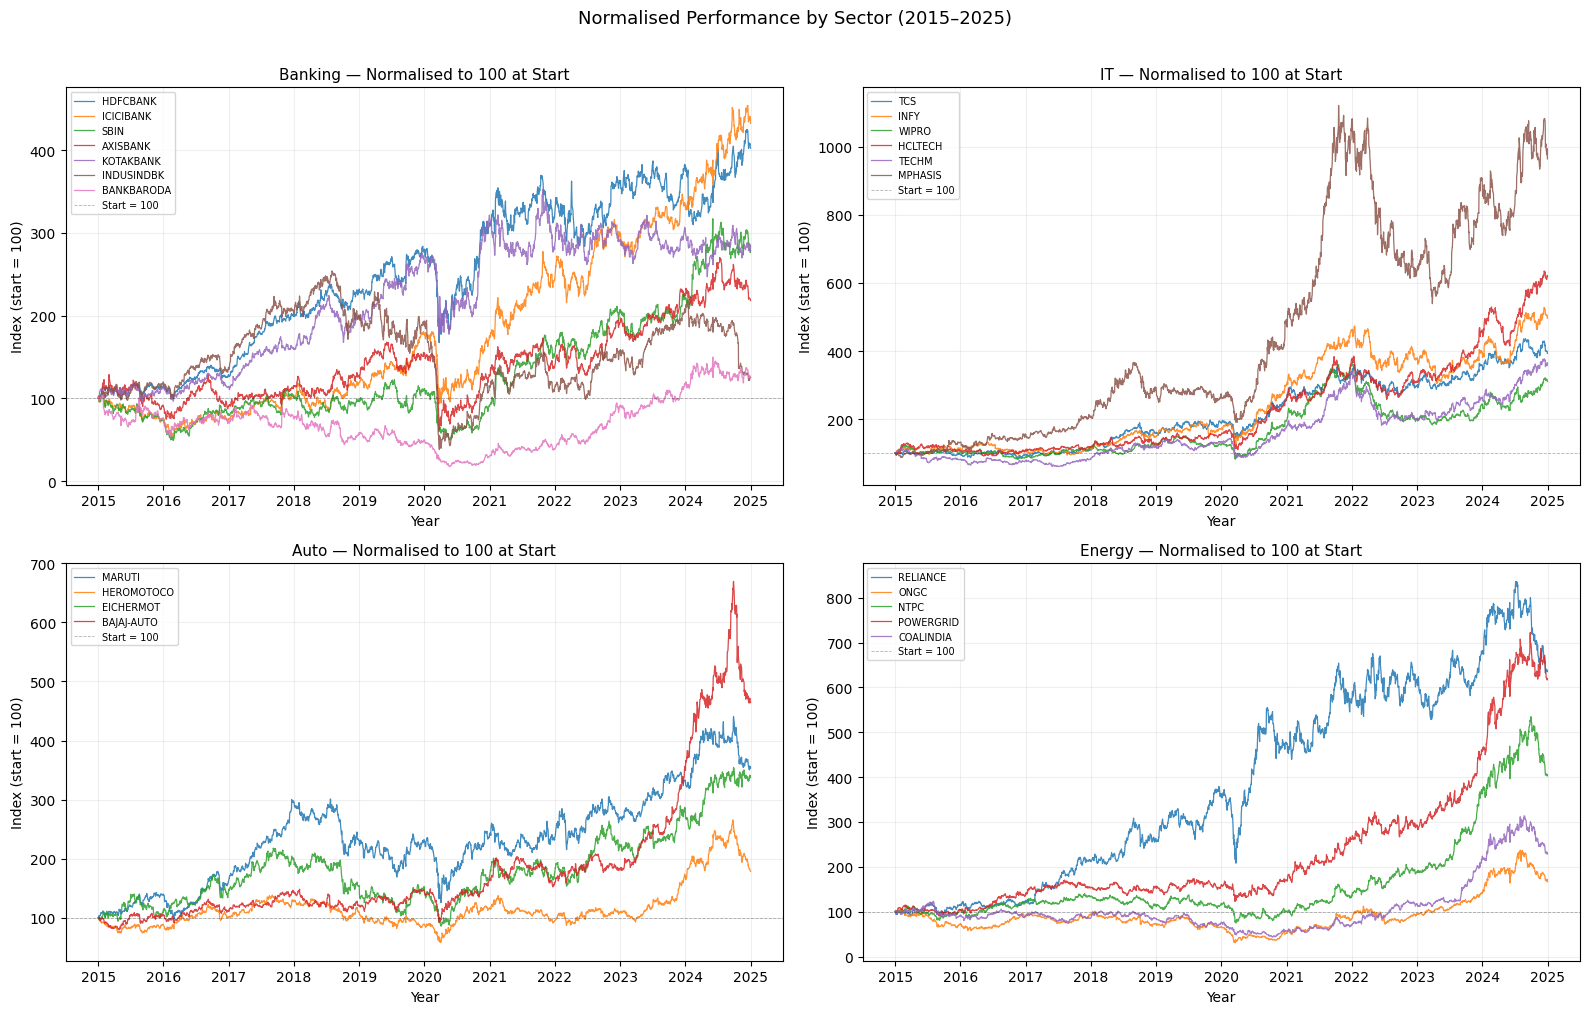

Saved: outputs/02_normalised_prices.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (sector_name, tickers) in enumerate(sectors.items()):
    ax    = axes[idx]
    valid = [t for t in tickers if t in prices_clean.columns]
    norm  = (prices_clean[valid] / prices_clean[valid].iloc[0]) * 100

    for i, ticker in enumerate(valid):
        ax.plot(
            norm.index,
            norm[ticker],
            label     = ticker.replace(".NS", ""),
            color     = colors[i],
            linewidth = 0.9,
            alpha     = 0.85,
        )

    ax.axhline(y=100, color="black", linestyle="--",
               linewidth=0.6, alpha=0.3, label="Start = 100")
    ax.set_title(f"{sector_name} — Normalised to 100 at Start", fontsize=11)
    ax.set_xlabel("Year")
    ax.set_ylabel("Index (start = 100)")
    ax.legend(fontsize=7, loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.2)

plt.suptitle("Normalised Performance by Sector (2015–2025)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../outputs/02_normalised_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/02_normalised_prices.png")

In [18]:
import json

# Master file — all stocks cleaned
prices_clean.to_csv("../data/nifty_prices_clean.csv")
print("Saved: data/nifty_prices_clean.csv")

# One file per sector
for sector_name, tickers in sectors.items():
    valid     = [t for t in tickers if t in prices_clean.columns]
    sector_df = prices_clean[valid]
    fname     = f"../data/sector_{sector_name.lower()}.csv"
    sector_df.to_csv(fname)
    print(f"Saved: {fname}  shape={sector_df.shape}")

# Save sectors dict so other notebooks can load it
sectors_clean = {
    k: [t for t in v if t in prices_clean.columns]
    for k, v in sectors.items()
}
with open("../data/sectors.json", "w") as f:
    json.dump(sectors_clean, f, indent=2)
print("Saved: data/sectors.json")

# Final summary
print("\n" + "="*45)
print("  PHASE 1 COMPLETE")
print("="*45)
print(f"  Stocks    : {prices_clean.shape[1]}")
print(f"  Days      : {prices_clean.shape[0]}")
print(f"  Date range: {prices_clean.index[0].date()} → {prices_clean.index[-1].date()}")
print(f"  Missing   : {prices_clean.isnull().sum().sum()}")
print("="*45)
print("\n  Next → open 02_eda_pairs.ipynb")


Saved: data/nifty_prices_clean.csv
Saved: ../data/sector_banking.csv  shape=(2467, 7)
Saved: ../data/sector_it.csv  shape=(2467, 6)
Saved: ../data/sector_auto.csv  shape=(2467, 4)
Saved: ../data/sector_energy.csv  shape=(2467, 5)
Saved: data/sectors.json

  PHASE 1 COMPLETE
  Stocks    : 22
  Days      : 2467
  Date range: 2015-01-01 → 2024-12-31
  Missing   : 0

  Next → open 02_eda_pairs.ipynb
